In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
agrupacion_horas = pd.read_csv("../data/agrupacion_horas.csv", sep=None, engine='python')
cierre_caja      = pd.read_csv("../data/cierre_caja.csv",      sep=None, engine='python')
compras_tpv      = pd.read_csv("../data/compras_tpv.csv",      sep=None, engine='python')
ventas_glovo     = pd.read_csv("../data/ventas_glovo.csv",     sep=None, engine='python')
compras_art      = pd.read_csv("../data/compras_articulos.csv",     sep=None, engine='python')

# Limpiar BOM y espacios en nombres de columnas
for df in [cierre_caja, compras_tpv, ventas_glovo]:
    df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()

# Copias de trabajo
horas  = agrupacion_horas.copy()
cierre = cierre_caja.copy()
ventas = compras_tpv.copy()
glovo  = ventas_glovo.copy()
compras=compras_art.copy()

print('Datos cargados correctamente')

Datos cargados correctamente


In [3]:
df1=compras.copy()
df1=df1.drop(columns=["OrderCode", "Brand", "Size", "Description"])
display(df1)


,ProductID,Name,Qty,Value,Discount,ValueIncVAT,ValueExcVAT,TotCost,Margin,MarginPerc
0,2160051,Doble Cara A4 Color,513,410.40,14.74,395.66,360.60,25.650,334.95,0.92887
1,2156338,10 Colores Mickey,1,5.89,0.00,5.89,4.87,3.460,1.41,0.28953
2,2154194,1200 Amarillo C-005,2,2.40,0.00,2.40,1.98,0.920,1.06,0.53535
3,2154182,1200 Azul C-010,2,2.40,0.00,2.40,1.98,0.920,1.06,0.53535
4,2154202,1200 Naranja Fluo C-066,2,2.40,0.00,2.40,1.98,0.920,1.06,0.53535
...,...,...,...,...,...,...,...,...,...,...
857,2153298,Velocity HB 0.5,5,7.75,0.00,7.75,6.40,2.300,4.10,0.64063
858,2153282,Velocity HB 0.7,5,7.75,0.00,7.75,6.40,2.800,3.60,0.56250
859,2155691,Verde Claro Fun 1.6,7,4.90,0.00,4.90,4.06,1.379,2.68,0.66034
860,2155700,Violeta Fun 1.6,10,7.00,0.00,7.00,5.80,1.970,3.83,0.66034


## Hipótesis 2
**"La existencia de productos con margen negativo se deben a que los precios han sido establecidos incorrectamente**


### Contexto del análisis

Se parte del dataset de trabajo df1 ya limpio. El objetivo es identificar los productos con margen absoluto negativo (Margin < 0), entender la causa raíz del problema para saber que medidas tomar.

El análisis se estructura en tres bloques:

| Bloque | Pregunta | Output |
|---|---|---|
| **1. Caracterización** | ¿Cuáles son y cuánto daño hacen? | Tabla + gráficos |
| **2. Causa raíz** | ¿Precio, descuento o coste? | Tabla clasificada por causa |
| **3. Recomendaciones** | ¿Qué hacer con cada uno? | Tabla de acciones + impacto estimado |

### Filtrado y Caracterización 

In [4]:
h2_agrupados=(
    df1.groupby("Name", as_index=False)
    .agg(Qty=("Qty","sum"),Value=("Value","sum"),Discount=("Discount","sum"),ValueExcVat=("ValueExcVAT","sum"),Costo=("TotCost","sum"),Margin= ("Margin","sum"))
)
display(h2_agrupados)

,Name,Qty,Value,Discount,ValueExcVat,Costo,Margin
0,10 Colores Mickey,1,5.89,0.0,4.87,3.460,1.41
1,1200 Amarillo C-005,2,2.40,0.0,1.98,0.920,1.06
2,1200 Azul C-010,2,2.40,0.0,1.98,0.920,1.06
3,1200 Naranja Fluo C-066,2,2.40,0.0,1.98,0.920,1.06
4,1200 Oro C-053,1,1.95,0.0,1.61,1.000,0.61
...,...,...,...,...,...,...,...
851,Velocity HB 0.5,5,7.75,0.0,6.40,2.300,4.10
852,Velocity HB 0.7,5,7.75,0.0,6.40,2.800,3.60
853,Verde Claro Fun 1.6,7,4.90,0.0,4.06,1.379,2.68
854,Violeta Fun 1.6,10,7.00,0.0,5.80,1.970,3.83


In [5]:
h2_agrupados["precio_unitario"]=h2_agrupados.Value/h2_agrupados.Qty
h2_agrupados["MarginPerc_real"]=h2_agrupados.Margin/h2_agrupados.ValueExcVat
h2_agrupados["Descuento_pct"]=h2_agrupados.Discount/h2_agrupados.Value
display(h2_agrupados)

,Name,Qty,Value,Discount,ValueExcVat,Costo,Margin,precio_unitario,MarginPerc_real,Descuento_pct
0,10 Colores Mickey,1,5.89,0.0,4.87,3.460,1.41,5.89,0.289528,0.0
1,1200 Amarillo C-005,2,2.40,0.0,1.98,0.920,1.06,1.20,0.535354,0.0
2,1200 Azul C-010,2,2.40,0.0,1.98,0.920,1.06,1.20,0.535354,0.0
3,1200 Naranja Fluo C-066,2,2.40,0.0,1.98,0.920,1.06,1.20,0.535354,0.0
4,1200 Oro C-053,1,1.95,0.0,1.61,1.000,0.61,1.95,0.378882,0.0
...,...,...,...,...,...,...,...,...,...,...
851,Velocity HB 0.5,5,7.75,0.0,6.40,2.300,4.10,1.55,0.640625,0.0
852,Velocity HB 0.7,5,7.75,0.0,6.40,2.800,3.60,1.55,0.562500,0.0
853,Verde Claro Fun 1.6,7,4.90,0.0,4.06,1.379,2.68,0.70,0.660099,0.0
854,Violeta Fun 1.6,10,7.00,0.0,5.80,1.970,3.83,0.70,0.660345,0.0


In [14]:
h2_negativos=h2_agrupados[h2_agrupados.Margin<0]
h2_negativos

,Name,Qty,Value,Discount,ValueExcVat,Costo,Margin,precio_unitario,MarginPerc_real,Descuento_pct
16,5 Boligrafos Bic Cristal,3,0.00,-6.75,6.75,8.25,-1.50,0.000,-0.222222,-inf
22,A4 Doble Cara Color Cartulina,49,51.45,9.29,42.16,51.45,-9.29,1.050,-0.220351,0.180564
56,Bic Cristal 10 azul bolsa,3,10.65,0.00,8.79,9.12,-0.33,3.550,-0.037543,0.000000
57,Bic Cristal 10 c bolsa,2,7.10,0.00,5.86,6.08,-0.22,3.550,-0.037543,0.000000
60,Bic Cristal 5 c bolsa,1,2.25,0.00,1.86,2.06,-0.20,2.250,-0.107527,0.000000
388,Intensity Pack 12,2,8.65,0.00,7.95,8.90,-0.95,4.325,-0.119497,0.000000
506,Pack 12 aquarela,1,3.65,0.00,3.02,3.09,-0.07,3.650,-0.023179,0.000000
609,Pizarra Board Master M,1,1.89,0.84,0.87,0.98,-0.11,1.890,-0.126437,0.444444


In [63]:
margin_min=h2_negativos.loc[h2_negativos.Margin.idxmin()]
margin_min
porcentaje=round(((len(h2_negativos)*100)/(len(h2_agrupados))))

In [64]:
print(f"El numero de productos con Margen negativos es de {len(h2_negativos)} en un total de {len(h2_agrupados)}")
print(f"Estos {len(h2_negativos)} productos suponen el {porcentaje}% del total de productos ")
print(f"El valor del producto con mayor margen negativo es {h2_negativos.Margin.min()} siendo {margin_min.Name} ")

El numero de productos con Margen negativos es de 8 en un total de 856
Estos 8 productos suponen el 1% del total de productos 
El valor del producto con mayor margen negativo es -9.29 siendo A4 Doble Cara Color Cartulina 


### 2. Visualización del impacto

Se representan los productos negativos en dos dimensiones:
- **Margen porcentual real (%):** cuán negativo es cada producto en términos relativos
- **Margen absoluto (€):** cuánto dinero está restando cada producto al negocio

/var/folders/fr/6cwshw4x50bfxr_7_37z_lmm0000gp/T/ipykernel_21695/3608862810.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Name", x="MarginPerc_real", data=h2_negativos, ax=ax[0], palette="Set2")
/var/folders/fr/6cwshw4x50bfxr_7_37z_lmm0000gp/T/ipykernel_21695/3608862810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Margin", y="Name", data=h2_negativos, palette="Set2", ax=ax[1])


<Axes: xlabel='Margin', ylabel='Name'>

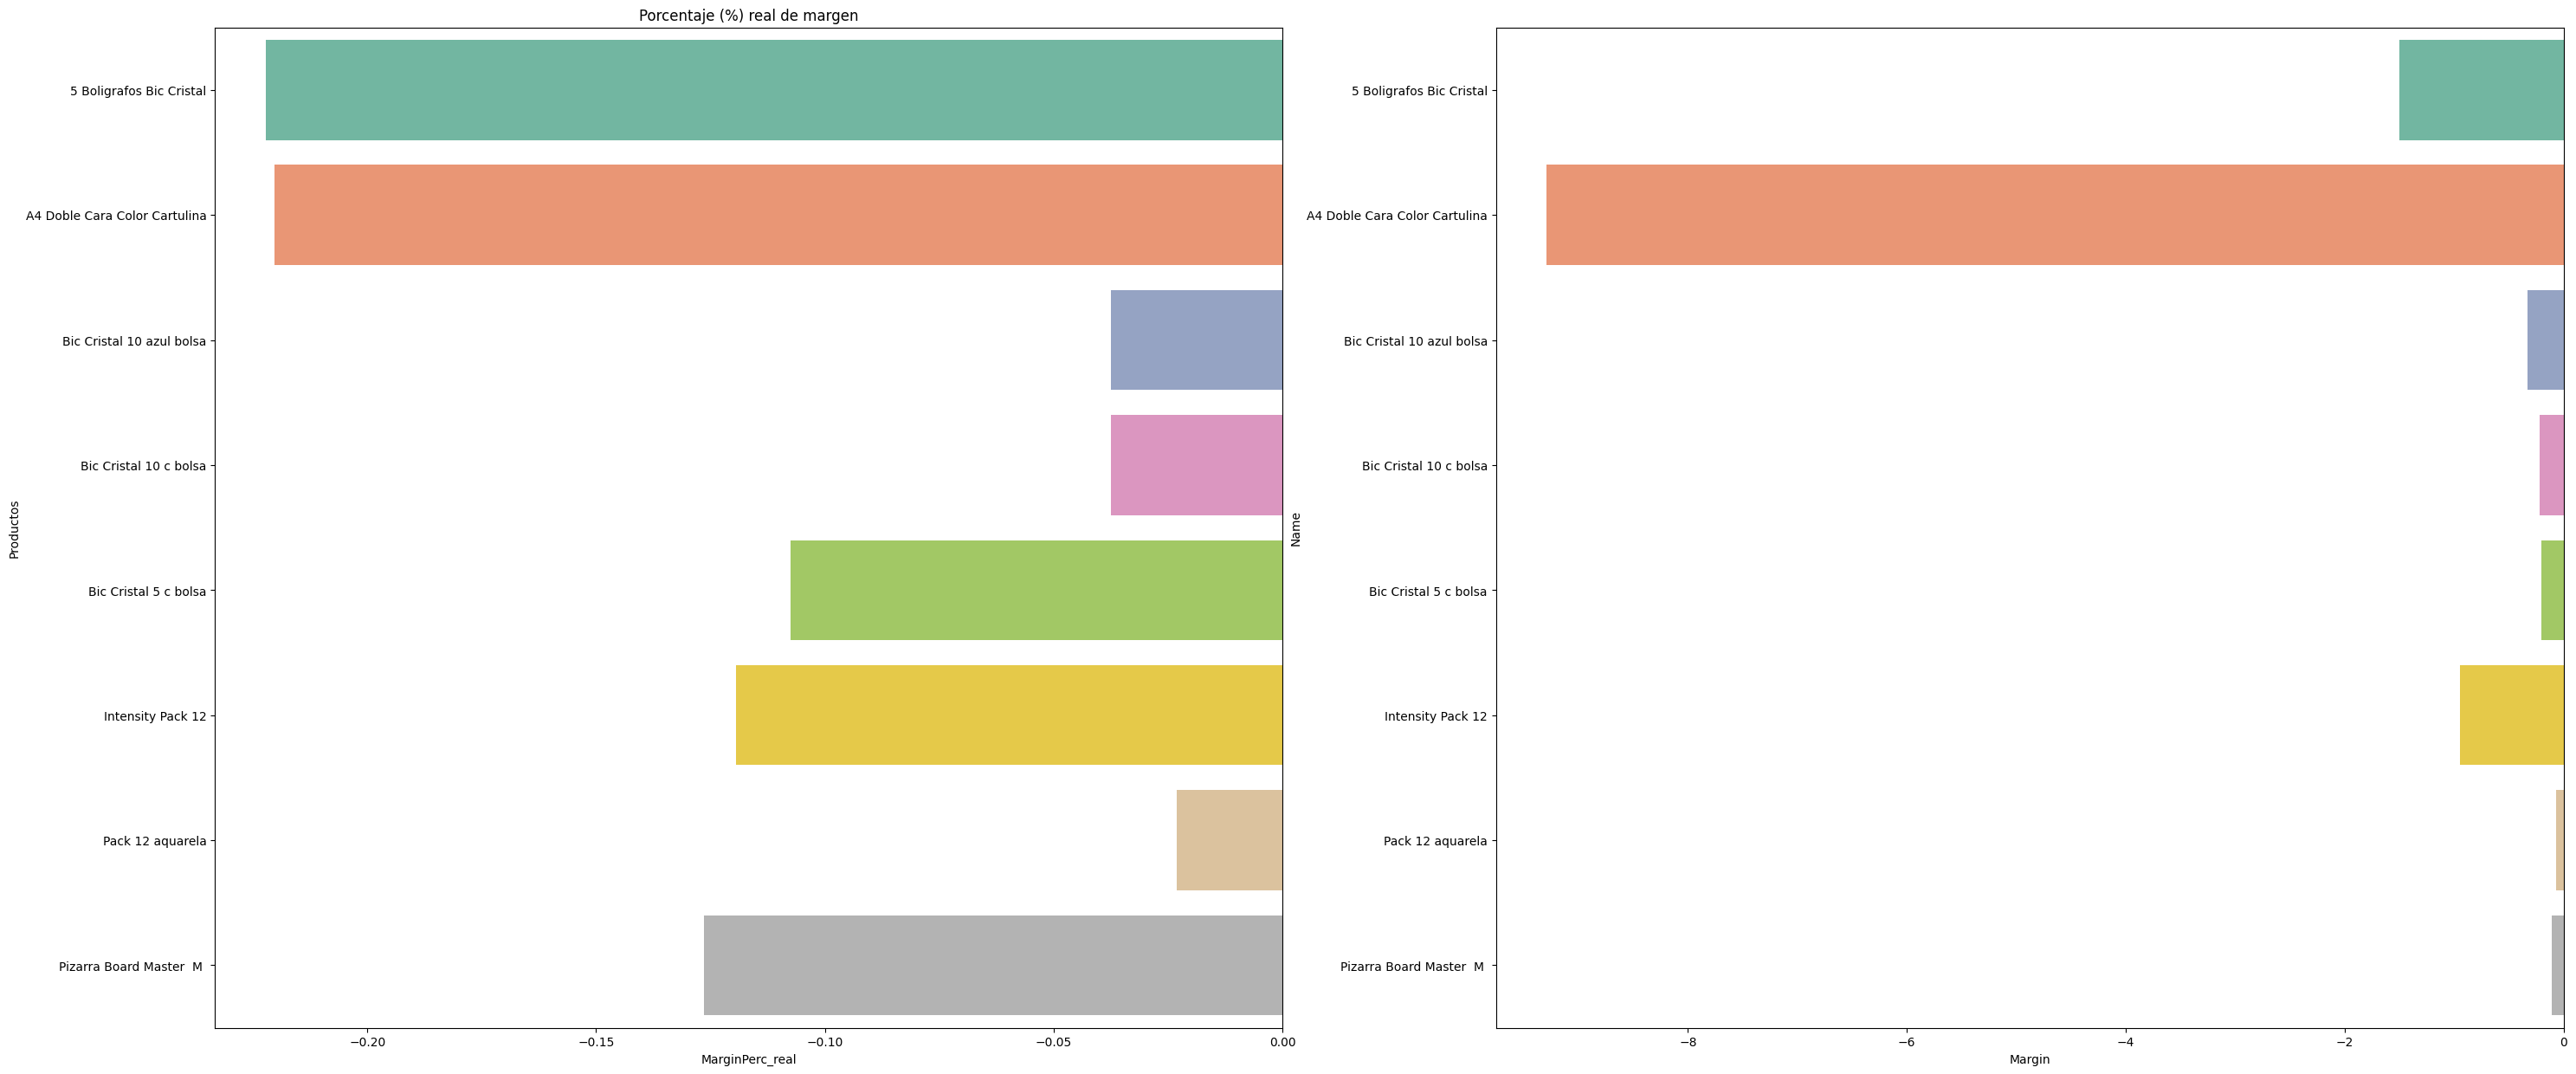

In [48]:
fig,ax=plt.subplots(1,2, figsize=(35,15))
sns.barplot(y="Name", x="MarginPerc_real", data=h2_negativos, ax=ax[0], palette="Set2")
ax[0].set_title("Porcentaje (%) real de margen")
ax[0].set_ylabel("Productos")

sns.barplot(x="Margin", y="Name", data=h2_negativos, palette="Set2", ax=ax[1])


In [56]:
display(h2_negativos)

,Name,Qty,Value,Discount,ValueExcVat,Costo,Margin,precio_unitario,MarginPerc_real,Descuento_pct
16,5 Boligrafos Bic Cristal,3,0.00,-6.75,6.75,8.25,-1.50,0.000,-0.222222,-inf
22,A4 Doble Cara Color Cartulina,49,51.45,9.29,42.16,51.45,-9.29,1.050,-0.220351,0.180564
56,Bic Cristal 10 azul bolsa,3,10.65,0.00,8.79,9.12,-0.33,3.550,-0.037543,0.000000
57,Bic Cristal 10 c bolsa,2,7.10,0.00,5.86,6.08,-0.22,3.550,-0.037543,0.000000
60,Bic Cristal 5 c bolsa,1,2.25,0.00,1.86,2.06,-0.20,2.250,-0.107527,0.000000
388,Intensity Pack 12,2,8.65,0.00,7.95,8.90,-0.95,4.325,-0.119497,0.000000
506,Pack 12 aquarela,1,3.65,0.00,3.02,3.09,-0.07,3.650,-0.023179,0.000000
609,Pizarra Board Master M,1,1.89,0.84,0.87,0.98,-0.11,1.890,-0.126437,0.444444


In [57]:
h2_negativos["costo_unitario"]=h2_negativos.Costo/h2_negativos.Qty
display(h2_negativos)

,Name,Qty,Value,Discount,ValueExcVat,Costo,Margin,precio_unitario,MarginPerc_real,Descuento_pct,costo_unitario
16,5 Boligrafos Bic Cristal,3,0.00,-6.75,6.75,8.25,-1.50,0.000,-0.222222,-inf,2.75
22,A4 Doble Cara Color Cartulina,49,51.45,9.29,42.16,51.45,-9.29,1.050,-0.220351,0.180564,1.05
56,Bic Cristal 10 azul bolsa,3,10.65,0.00,8.79,9.12,-0.33,3.550,-0.037543,0.000000,3.04
57,Bic Cristal 10 c bolsa,2,7.10,0.00,5.86,6.08,-0.22,3.550,-0.037543,0.000000,3.04
60,Bic Cristal 5 c bolsa,1,2.25,0.00,1.86,2.06,-0.20,2.250,-0.107527,0.000000,2.06
388,Intensity Pack 12,2,8.65,0.00,7.95,8.90,-0.95,4.325,-0.119497,0.000000,4.45
506,Pack 12 aquarela,1,3.65,0.00,3.02,3.09,-0.07,3.650,-0.023179,0.000000,3.09
609,Pizarra Board Master M,1,1.89,0.84,0.87,0.98,-0.11,1.890,-0.126437,0.444444,0.98


In [59]:
iva=0.21
h2_negativos["precio_sinIVA"]=h2_negativos.precio_unitario/(1+iva)
display(h2_negativos)

,Name,Qty,Value,Discount,ValueExcVat,Costo,Margin,precio_unitario,MarginPerc_real,Descuento_pct,costo_unitario,precio_sinIVA
16,5 Boligrafos Bic Cristal,3,0.00,-6.75,6.75,8.25,-1.50,0.000,-0.222222,-inf,2.75,0.000000
22,A4 Doble Cara Color Cartulina,49,51.45,9.29,42.16,51.45,-9.29,1.050,-0.220351,0.180564,1.05,0.867769
56,Bic Cristal 10 azul bolsa,3,10.65,0.00,8.79,9.12,-0.33,3.550,-0.037543,0.000000,3.04,2.933884
57,Bic Cristal 10 c bolsa,2,7.10,0.00,5.86,6.08,-0.22,3.550,-0.037543,0.000000,3.04,2.933884
60,Bic Cristal 5 c bolsa,1,2.25,0.00,1.86,2.06,-0.20,2.250,-0.107527,0.000000,2.06,1.859504
388,Intensity Pack 12,2,8.65,0.00,7.95,8.90,-0.95,4.325,-0.119497,0.000000,4.45,3.574380
506,Pack 12 aquarela,1,3.65,0.00,3.02,3.09,-0.07,3.650,-0.023179,0.000000,3.09,3.016529
609,Pizarra Board Master M,1,1.89,0.84,0.87,0.98,-0.11,1.890,-0.126437,0.444444,0.98,1.561983


<Axes: xlabel='costo_unitario', ylabel='Margin'>

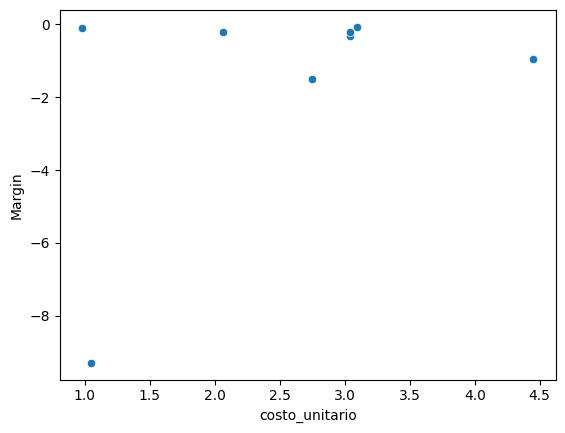

In [ ]:
total_marge_negativo=h2_negativos.Margin.sum()
tmn=total_marge_negativo
tmn

sns.scatterplot(x="costo_unitario",y="Margin", data=h2_negativos)


# Conclusion
Solo 8 de los 856 productos presentan margen negativo, lo que representa menos del 1 % del catálogo total. En términos absolutos, el impacto individual es reducido: el producto con mayor pérdida **A4 Doble Cara Color Cartulina** acumula un margen de 9,29 €

Causas identificadas: 
- Descuentos: Existen dos productos con descuetos: 
    - Bolígrafos Bic Cristal presentan un descuento que supera el valor de venta registrado (valor = 0,00 €, descuento = −6,75 €), lo que sugiere una devolución o corrección mal imputada, o un descuento aplicado incorrectamente.
    - A4 Doble Cara Color presenan un descuento de 9,29 € que casualmente representa el margen de ganancia, lo que hace que con este producto la rentabilidad es 0

- Productos con precios mal establecidos:
    - Los productos con margen negativos tienen un problema adicional. El precio del producto sin IVA es menor que el precio de coste lo que genera un resultado de margen negativo